# Import Libraries

In [86]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load & Inspect

### Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Mega Store\OneDrive\Documents\ITI - AI & Machine Learning (Level 1)\Project\house_prices.csv")

### Display First Rows

In [3]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


### Shape of Dataset (Rows & Columns)

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 187531
Columns : 21


### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

### Statistical Summary

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Duplicate Rows

In [13]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Missing Values

In [14]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09


### Numeric Columns

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['Index', 'Price (in rupees)', 'Dimensions', 'Plot Area'], dtype='object')

### Categorical Columns

In [19]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Title', 'Description', 'Amount(in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='object')

### Dataset Inspection

During the initial inspection, we observed:

- The dataset contains **187531** rows and **21** columns.
- Most features are categorical (object type), while only a few are numerical.
- Several columns contain missing values that must be handled before model training.
- Features such as **Amount(in rupees)**, **Carpet Area**, and **Floor** are stored as text and require preprocessing before they can be used in a machine learning model.

# Exploratory Data Analysis (EDA)

### Convert the Target Variable (Price)

In [21]:
def parse_price(price):

    if pd.isna(price):
        return np.nan

    price = str(price).strip().lower()

    try:
        if "lac" in price:
            return float(price.replace("lac", "").strip()) * 100000

        elif "cr" in price:
            return float(price.replace("cr", "").strip()) * 10000000

        else:
            return np.nan

    except:
        return np.nan

df["price_clean"] = df["Amount(in rupees)"].apply(parse_price)

In [22]:
df[["Amount(in rupees)", "price_clean"]].head()

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


### Convert Carpet Area

In [24]:
def extract_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    value = re.findall(r"\d+\.?\d*", area)

    if len(value) == 0:
        return np.nan

    value = float(value[0])

    if "sqm" in area:
        value *= 10.764

    return value

df["carpet_area_sqft"] = df["Carpet Area"].apply(extract_area)

### Plot 1: Distribution of Target Price

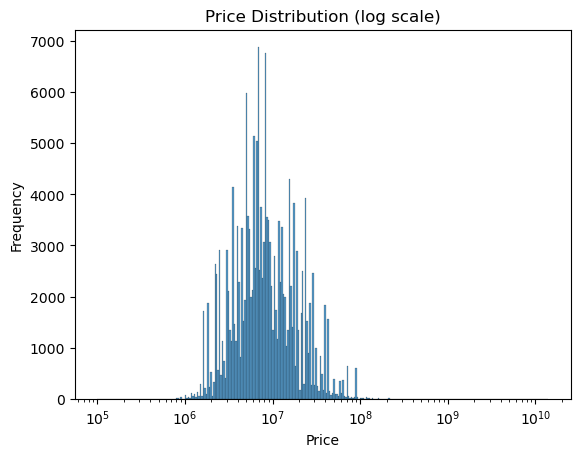

In [32]:
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price Distribution (log scale)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

The distribution of house prices is highly right-skewed. Most properties have relatively low prices, while only a few luxury houses have very high prices.
A logarithmic scale makes the distribution easier to interpret.

### Plot 2: Price vs Carpet Area

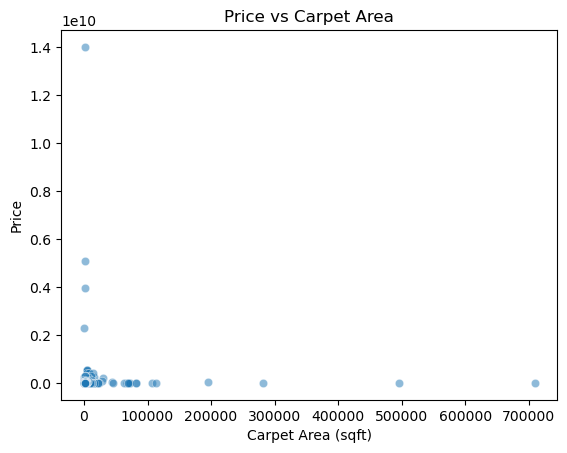

In [33]:
sns.scatterplot(data=df, x="carpet_area_sqft", y="price_clean", alpha=0.5)
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")
plt.show()

There is a positive relationship between carpet area and house price. Larger houses generally have higher prices, although a few outliers are present.

### Plot 3: Average Price by Top 15 Locations

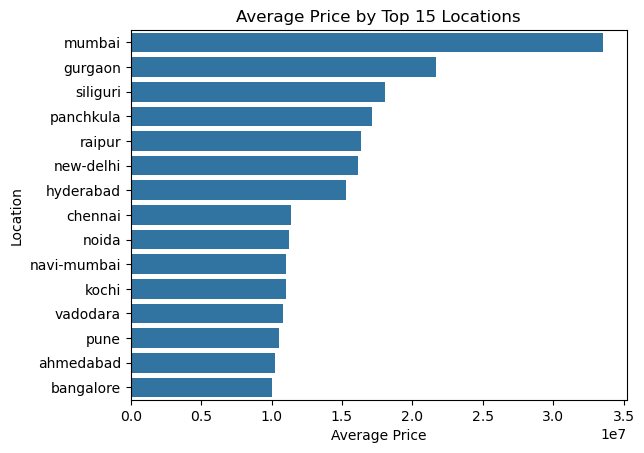

In [34]:
top_locations = (
    df.groupby("location")["price_clean"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price")
plt.ylabel("Location")
plt.show()

House prices vary significantly across different locations. This suggests that location is one of the most important features for predicting property prices.

### Plot 4: Price by Furnishing Status

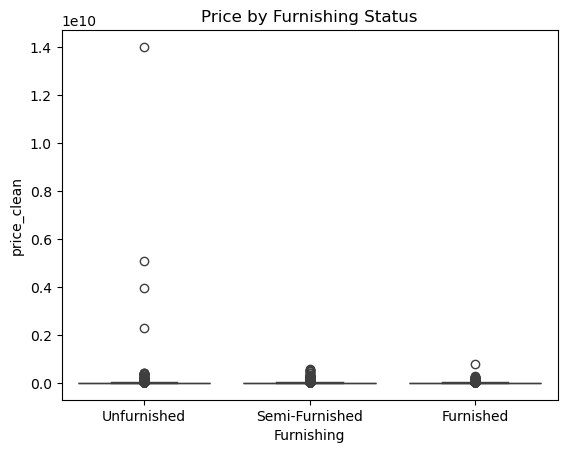

In [37]:
sns.boxplot(data=df, x="Furnishing", y="price_clean")
plt.title("Price by Furnishing Status")
plt.xticks()
plt.show()

Furnished properties generally have higher median prices than unfurnished properties, although there is overlap between categories.

### Plot 5: Price by Number of Bathrooms

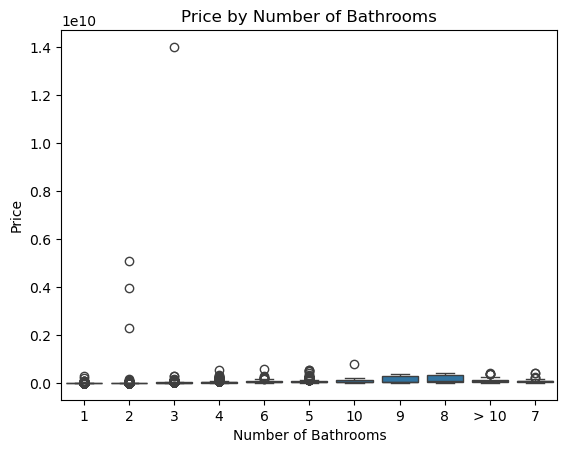

In [38]:
sns.boxplot(data=df, x="Bathroom", y="price_clean")
plt.title("Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.show()

Houses with more bathrooms generally tend to have higher prices, indicating that bathroom count may be an important predictor.

### Plot 6: Missing Values Percentage

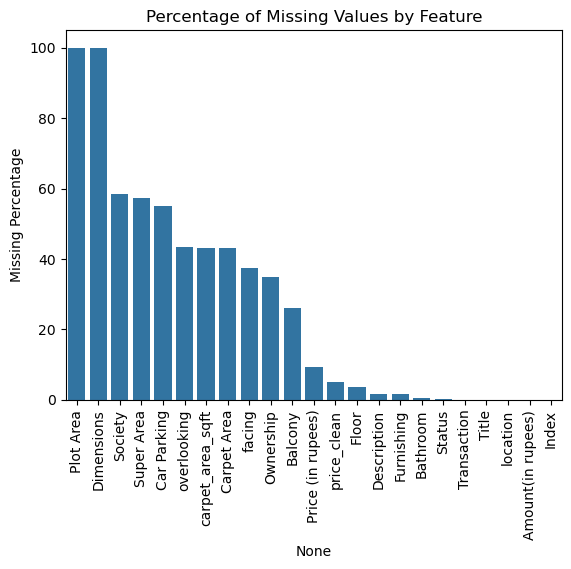

In [41]:
missing = (df.isnull().sum() / len(df)) * 100
missing = missing.sort_values(ascending=False)

sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.ylabel("Missing Percentage")
plt.title("Percentage of Missing Values by Feature")
plt.show()

Several features contain missing values, which will need to be handled during the data cleaning and preprocessing stage before model training.

# Cleaning & Feature Engineering

### Remove Rows Without Price

In [43]:
df = df.dropna(subset=["price_clean"])
print(df.shape)

(177847, 23)


### Clean Carpet Area

In [44]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1235.758917
std        3132.990809
min           1.000000
25%         780.000000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

In [45]:
df = df[df["carpet_area_sqft"] > 0]

### Clean Super Area

In [46]:
def extract_super_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    number = re.findall(r"\d+\.?\d*", area)

    if len(number) == 0:
        return np.nan

    value = float(number[0])

    if "sqm" in area:
        value *= 10.764

    return value

df["super_area_sqft"] = df["Super Area"].apply(extract_super_area)

### Extract Floor Number

In [47]:
def extract_floor(floor):

    if pd.isna(floor):
        return np.nan

    floor = str(floor).lower()

    if "ground" in floor:
        return 0

    if "basement" in floor:
        return -1

    number = re.findall(r"\d+", floor)

    if len(number) == 0:
        return np.nan

    return int(number[0])

df["floor_num"] = df["Floor"].apply(extract_floor)

### Convert Numeric Features

In [48]:
numeric_columns = ["Bathroom", "Balcony", "Car Parking"]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

### Handle Missing Values

In [69]:
df["Bathroom"].fillna(df["Bathroom"].median(), inplace=True)

df["Balcony"].fillna(df["Balcony"].median(), inplace=True)

df["Car Parking"].fillna(0, inplace=True)

df["floor_num"].fillna(df["floor_num"].median(), inplace=True)

df["carpet_area_sqft"].fillna(df["carpet_area_sqft"].median(), inplace=True)

df["super_area_sqft"].fillna(df["super_area_sqft"].median(), inplace=True)

### Group Rare Locations

In [51]:
top_locations = df["location"].value_counts().nlargest(50).index

df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)

### Fill Missing Categories

In [70]:
categorical_columns = [
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing",
    "location_grouped"
]

for col in categorical_columns:
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

### Drop Useless Columns

In [53]:
drop_columns = [
    "Title",
    "Description",
    "Dimensions",
    "Amount(in rupees)",
    "location",
    "Society"
]

df.drop(columns=drop_columns, inplace=True, errors="ignore")

### Remove Duplicates

In [54]:
df.drop_duplicates(inplace=True)

### Remove Outliers

In [55]:
lower = df["price_clean"].quantile(0.01)

upper = df["price_clean"].quantile(0.99)

df = df[
    (df["price_clean"] >= lower)
    &
    (df["price_clean"] <= upper)
]

### Final Dataset

In [56]:
df.head()

,Index,Price (in rupees),Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area,Plot Area,price_clean,carpet_area_sqft,super_area_sqft,floor_num,location_grouped
0,0,6000.0,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,East,NaN,1.0,2.0,0.0,Freehold,NaN,NaN,4200000.0,500.0,NaN,10.0,thane
1,1,13799.0,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,1.0,Freehold,NaN,NaN,9800000.0,473.0,NaN,3.0,thane
2,2,17500.0,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,2.0,2.0,1.0,Freehold,NaN,NaN,14000000.0,779.0,NaN,10.0,thane
3,3,NaN,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,East,NaN,1.0,1.0,0.0,Freehold,NaN,NaN,2500000.0,530.0,NaN,1.0,thane
4,4,18824.0,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,1.0,Co-operative Society,NaN,NaN,16000000.0,635.0,NaN,20.0,thane


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99835 entries, 0 to 187528
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              99835 non-null  int64  
 1   Price (in rupees)  92069 non-null  float64
 2   Carpet Area        99835 non-null  object 
 3   Status             99762 non-null  object 
 4   Floor              97673 non-null  object 
 5   Transaction        99835 non-null  object 
 6   Furnishing         99835 non-null  object 
 7   facing             99835 non-null  object 
 8   overlooking        73636 non-null  object 
 9   Bathroom           99835 non-null  float64
 10  Balcony            99835 non-null  float64
 11  Car Parking        99835 non-null  float64
 12  Ownership          99835 non-null  object 
 13  Super Area         0 non-null      object 
 14  Plot Area          0 non-null      float64
 15  price_clean        99835 non-null  float64
 16  carpet_area_sqft   99835 n

In [58]:
df.describe()

,Index,Price (in rupees),Bathroom,Balcony,Car Parking,Plot Area,price_clean,carpet_area_sqft,super_area_sqft,floor_num
count,99835.000000,9.206900e+04,99835.000000,99835.000000,99835.000000,0.0,9.983500e+04,99835.000000,0.0,99835.000000
mean,99938.777894,7.901318e+03,2.520940,2.046807,2.777303,NaN,1.247497e+07,1213.517471,NaN,4.619001
std,52536.679549,1.561783e+04,0.865617,0.926719,26.878854,NaN,1.125631e+07,3140.820864,NaN,4.872227
min,0.000000,0.000000e+00,1.000000,1.000000,0.000000,NaN,1.800000e+06,1.000000,NaN,-1.000000
25%,57375.500000,4.624000e+03,2.000000,1.000000,0.000000,NaN,5.000000e+06,780.000000,NaN,2.000000
50%,106017.000000,6.316000e+03,2.000000,2.000000,1.000000,NaN,8.100000e+06,1050.000000,NaN,3.000000
75%,142189.500000,1.050000e+04,3.000000,3.000000,1.000000,NaN,1.700000e+07,1500.000000,NaN,6.000000
max,187528.000000,4.500000e+06,10.000000,10.000000,999.000000,NaN,7.000000e+07,709222.000000,NaN,60.000000


### Cleaning & Feature Engineering Summary

The dataset required extensive preprocessing before it could be used for machine learning.

The main preprocessing steps included:

- Converting the target price from text to numeric values.
- Extracting carpet and super area measurements in square feet.
- Extracting the floor number from text values.
- Converting bathroom, balcony, and parking features to numeric values.
- Handling missing values using the median for numerical features and the mode for categorical features.
- Grouping infrequent locations into an "Other" category to reduce the dimensionality of categorical variables.
- Removing duplicate records and extreme outliers.
- Dropping unnecessary descriptive columns that do not contribute to prediction.

The cleaned dataset is now ready for preprocessing and model training.

# Model Building & Training

### Define Features and Target

In [60]:
# Target variable
y = df["price_clean"]

# Features
X = df.drop(columns=["price_clean"])

### Identify Numerical and Categorical Features

In [61]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Index', 'Price (in rupees)', 'Bathroom', 'Balcony', 'Car Parking', 'Plot Area', 'carpet_area_sqft', 'super_area_sqft', 'floor_num']

Categorical Features:
['Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'Super Area', 'location_grouped']


### Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Numerical Pipeline

In [63]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

### Categorical Pipeline

In [64]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

### Combine Both Pipelines

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Create the Models

In [74]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=1),

    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=1, n_jobs=-1),

    "Gradient Boosting": GradientBoostingRegressor(random_state=1)

}

### Train All Models

In [75]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


# Evaluation

### Evaluate Every Model

In [76]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

### Comparison Table

In [77]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,MAE,RMSE,R² Score
2,Random Forest,4.134490e+05,1.449538e+06,0.983373
1,Decision Tree,5.023153e+05,1.745782e+06,0.975882
3,Gradient Boosting,1.068191e+06,2.022272e+06,0.967638
0,Linear Regression,1.379091e+06,3.521611e+07,-8.813920


### Visual Comparison

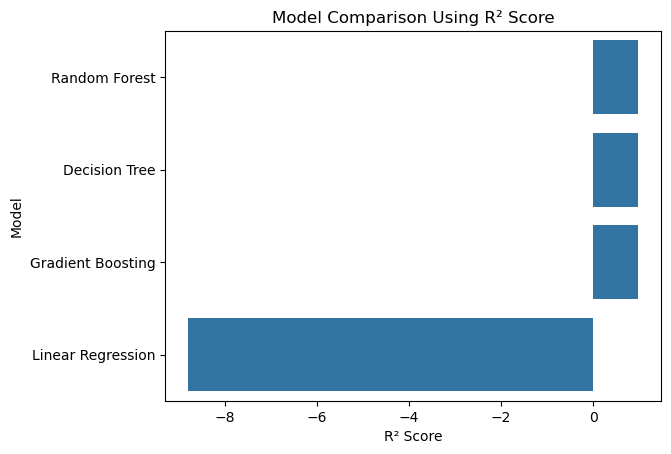

In [78]:
sns.barplot(
    data=results_df,
    x="R² Score",
    y="Model"
)
plt.title("Model Comparison Using R² Score")
plt.show()

### Best Model

In [79]:
best_model = results_df.iloc[0]["Model"]
print("Best Model:", best_model)

Best Model: Random Forest


### Actual vs Predicted (Best Model)

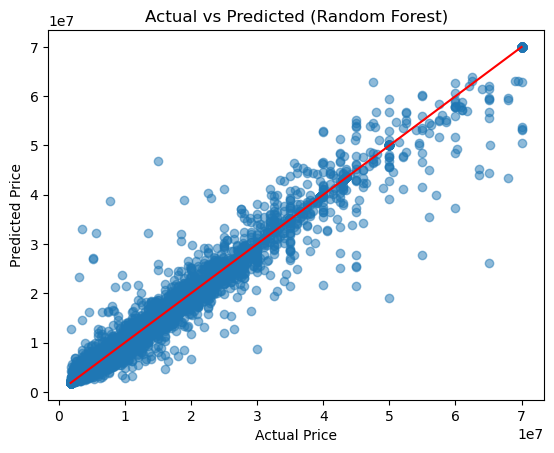

In [85]:
best_pipeline = trained_models[best_model]

predictions = best_pipeline.predict(X_test)

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model})")
plt.show()

### Model Comparison Summary

Four regression models were trained and evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

The models were compared using MAE, RMSE, and R² Score.

Among the evaluated models, **Random Forest** achieved the highest R² Score and the lowest prediction error, making it the most suitable model for house price prediction on this dataset.

# Export the Model

### Save the Best Model

In [88]:
joblib.dump(best_pipeline, "house_price.pkl")

print("Model saved successfully!")

Model saved successfully!


### Reload the Model (Sanity Check)

In [89]:
loaded_model = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Reloaded Prediction:", prediction)

Reloaded Prediction: [9500000.]


### Save the Locations

In [90]:
locations = sorted(df["location_grouped"].unique().tolist())

with open("locations.json", "w") as f:
    json.dump(locations, f)

print("locations.json saved successfully!")

locations.json saved successfully!


### Verify the Files Exist

In [91]:
print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in Current Directory:")
print(os.listdir())

Current Working Directory:
C:\Users\Mega Store\ITI - AI & Machine Learning (Level 1)\Project

Files in Current Directory:
['.ipynb_checkpoints', 'house_price.pkl', 'house_prices.csv', 'house_price_model.pkl', 'ITI_Project.ipynb', 'locations.json']


### Save Everything Inside a models Folder

In [93]:
# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(best_pipeline, "models/house_price.pkl")

# Save locations
with open("models/locations.json", "w") as file:
    json.dump(locations, file)

print("Files saved successfully!")

print(os.listdir("models"))

Files saved successfully!
['house_price.pkl', 'locations.json']


### Model Export Summary

The best-performing regression model was selected based on the evaluation metrics (MAE, RMSE, and R² Score). The trained pipeline, including all preprocessing steps and the regression model, was saved using the `joblib` library as `house_price_model.pkl`.

Additionally, the list of available property locations was exported as `locations.json` to support the location dropdown menu in the web application. These files will be used by the FastAPI backend to make predictions without retraining the model.